# Alarms Analysis


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

alarms = pd.read_csv("Luotea-Hackathon-2026/Alarms/alarms.csv")
alarms["EVENT_TIME"] = pd.to_datetime(alarms["EVENT_TIME"])
alarms["EVENT_CLOSED_TIME"] = pd.to_datetime(alarms["EVENT_CLOSED_TIME"])

print(f"Rows: {len(alarms):,}  |  Columns: {alarms.shape[1]}")
print(f"Date range: {alarms['EVENT_TIME'].min().date()} → {alarms['EVENT_TIME'].max().date()}")
alarms.head()

Rows: 18,702  |  Columns: 25
Date range: 2025-01-20 → 2026-05-25


,ALERT_EVENT_ID,ALERT_EVENT_LAST_UPDATED,CUSTOMER_NO,CUSTOMER_NAME,CUSTOMER_SITE_NO,CUSTOMER_SITE_NAME,SITE_ADDRESS,CONTRACT_NO,EVENT_TIME,ALERT_ID,...,Priority,LOG_ONLY,EVENT_DESCRIPTION,WORKORDER_NO,EVENT_CLOSED_TIME,LOCATION_ID,LOCATION_TABLE_ID,LOCATION_LAST_UPDATED,IVA_NO,STATUS
0,5701,2026-06-01 07:00:01.533,100000413,Valmet Technologies Oy,998389833,Lentokentänkatu 11,Lentokentänkatu 11 33900 Tampere FINLAND,10108694,2025-04-13 13:45:12,5162501,...,60,NaN,"Sarankulman kiinteistö, PRI:1, PALAUTUNUT, 13....",NaN,2025-04-13 13:46:39,4218,4218,2026-06-01 07:00:01.063,5101,Valvonnassa
1,5702,2026-06-01 07:00:01.533,100000413,Valmet Technologies Oy,998389833,Lentokentänkatu 11,Lentokentänkatu 11 33900 Tampere FINLAND,10108694,2025-04-13 13:45:12,5162501,...,60,NaN,"Sarankulman kiinteistö, PRI:1, PALAUTUNUT, 13....",NaN,2025-04-13 13:46:39,4219,4219,2026-06-01 07:00:01.063,5101,Valvonnassa
2,8435,2026-06-01 07:00:01.533,100279959,Valmet Flow Control Oy,999488386,Toimistotalo,Vanha Porvoontie 229 01380 Vantaa FINLAND,100097484,2025-12-04 13:27:47,5855402,...,77,NaN,/Palolaitevika,NaN,2025-12-04 14:51:25,3147,3147,2026-06-01 07:00:01.063,5454,Valvonnassa
3,8436,2026-06-01 07:00:01.533,100279959,Valmet Flow Control Oy,999488386,Toimistotalo,Vanha Porvoontie 229 01380 Vantaa FINLAND,100097484,2025-12-04 13:27:47,5855402,...,77,NaN,/Palolaitevika,NaN,2025-12-04 14:51:25,3148,3148,2026-06-01 07:00:01.063,5454,Valvonnassa
4,8437,2026-06-01 07:00:01.533,100279959,Valmet Flow Control Oy,999488386,Toimistotalo,Vanha Porvoontie 229 01380 Vantaa FINLAND,100097484,2025-12-04 13:27:47,5855402,...,77,NaN,/Palolaitevika,NaN,2025-12-04 14:51:25,3149,3149,2026-06-01 07:00:01.063,5454,Valvonnassa


## Data Quality

In [23]:
nulls = alarms.isnull().sum()
nulls_pct = (nulls / len(alarms) * 100).round(1)
quality = pd.DataFrame({"null_count": nulls, "null_%": nulls_pct, "unique_values": alarms.nunique()})
quality[quality["null_count"] > 0]

,null_count,null_%,unique_values
LOOP,106,0.6,8
ALERT_TYPE,106,0.6,8
LOG_ONLY,12346,66.0,1
WORKORDER_NO,17846,95.4,152
EVENT_CLOSED_TIME,40,0.2,1011


## Alarms by Site and Type

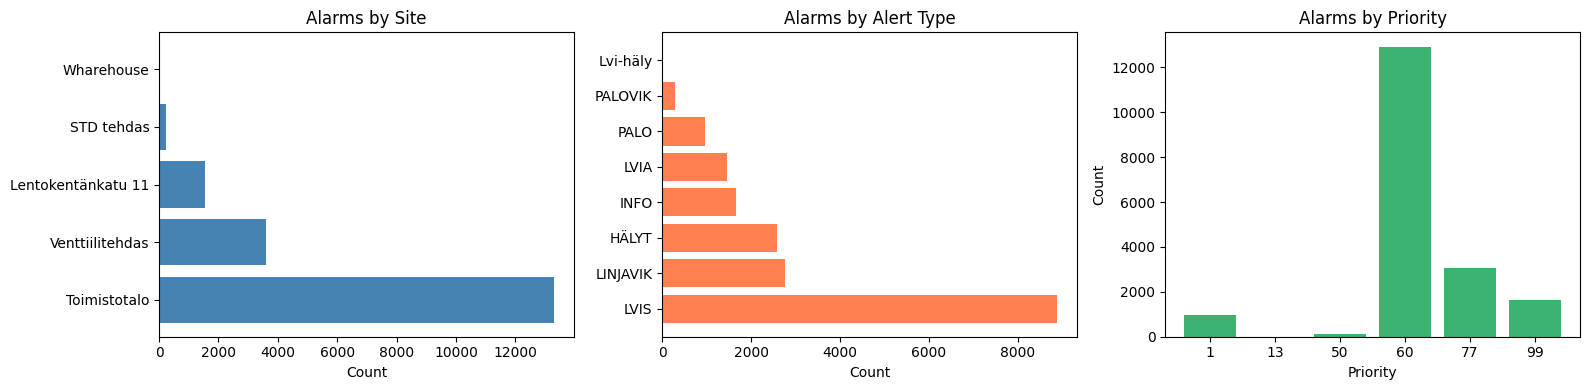

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Alarms by site
site_counts = alarms["CUSTOMER_SITE_NAME"].value_counts()
axes[0].barh(site_counts.index, site_counts.values, color="steelblue")
axes[0].set_title("Alarms by Site")
axes[0].set_xlabel("Count")

# Alarms by alert type
type_counts = alarms["ALERT_TYPE"].value_counts()
axes[1].barh(type_counts.index, type_counts.values, color="coral")
axes[1].set_title("Alarms by Alert Type")
axes[1].set_xlabel("Count")

# Alarms by priority
prio_counts = alarms["Priority"].value_counts().sort_index()
axes[2].bar(prio_counts.index.astype(str), prio_counts.values, color="mediumseagreen")
axes[2].set_title("Alarms by Priority")
axes[2].set_xlabel("Priority")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Monthly Alarm Volume

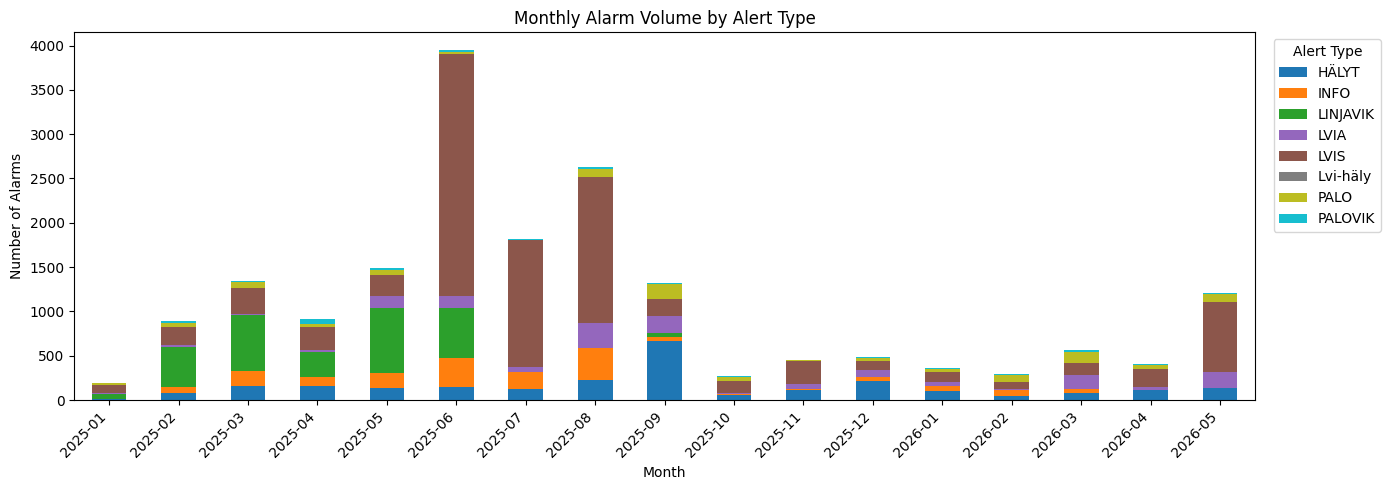

In [25]:
alarms["month"] = alarms["EVENT_TIME"].dt.to_period("M")

monthly = (
    alarms.groupby(["month", "ALERT_TYPE"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
monthly.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Monthly Alarm Volume by Alert Type")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Alarms")
ax.set_xticklabels([str(p) for p in monthly.index], rotation=45, ha="right")
ax.legend(title="Alert Type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Resolution Time Analysis

Resolution time (minutes) summary:
count    18662.0
mean       494.0
std       2492.6
min          0.0
25%          1.3
50%         12.5
75%        106.6
max      50095.4
Name: resolution_min, dtype: float64


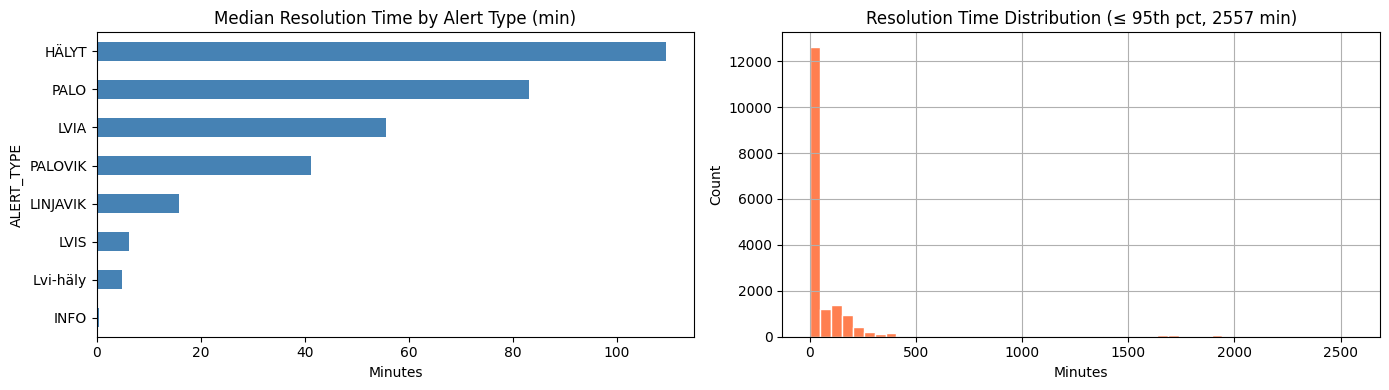

In [26]:
df_closed = alarms[alarms["EVENT_CLOSED_TIME"].notna()].copy()
df_closed["resolution_min"] = (
    (df_closed["EVENT_CLOSED_TIME"] - df_closed["EVENT_TIME"]).dt.total_seconds() / 60
)

print("Resolution time (minutes) summary:")
print(df_closed["resolution_min"].describe().round(1))

# Median resolution by alert type
med_by_type = df_closed.groupby("ALERT_TYPE")["resolution_min"].median().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

med_by_type.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Median Resolution Time by Alert Type (min)")
axes[0].set_xlabel("Minutes")

# Distribution (capped at 95th percentile for readability)
cap = df_closed["resolution_min"].quantile(0.95)
df_closed[df_closed["resolution_min"] <= cap]["resolution_min"].hist(
    bins=50, ax=axes[1], color="coral", edgecolor="white"
)
axes[1].set_title(f"Resolution Time Distribution (≤ 95th pct, {cap:.0f} min)")
axes[1].set_xlabel("Minutes")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Work Order Linkage

            with_wo  total  rate_%
ALERT_TYPE                        
INFO            828   1656    50.0
HÄLYT             0   2579     0.0
LINJAVIK          0   2770     0.0
LVIA              0   1458     0.0
LVIS              0   8882     0.0
Lvi-häly          0      1     0.0
PALO              0    970     0.0
PALOVIK           0    280     0.0


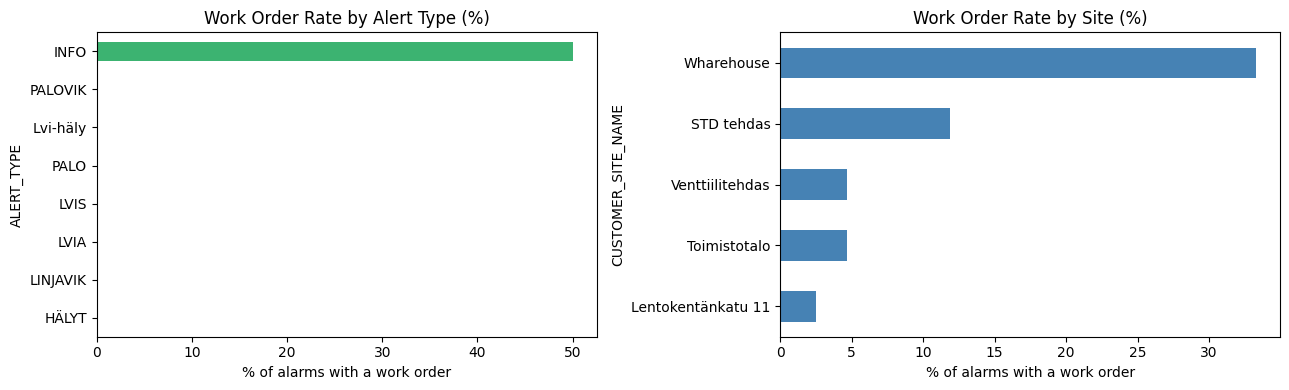

In [27]:
alarms["has_workorder"] = alarms["WORKORDER_NO"].notna()

# Work order rate by alert type
wo_rate = (
    alarms.groupby("ALERT_TYPE")["has_workorder"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "with_wo", "count": "total"})
)
wo_rate["rate_%"] = (wo_rate["with_wo"] / wo_rate["total"] * 100).round(1)
print(wo_rate.sort_values("rate_%", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Rate by alert type
wo_rate["rate_%"].sort_values().plot(kind="barh", ax=axes[0], color="mediumseagreen")
axes[0].set_title("Work Order Rate by Alert Type (%)")
axes[0].set_xlabel("% of alarms with a work order")

# Rate by site
wo_site = (
    alarms.groupby("CUSTOMER_SITE_NAME")["has_workorder"]
    .mean()
    .mul(100)
    .round(1)
    .sort_values()
)
wo_site.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Work Order Rate by Site (%)")
axes[1].set_xlabel("% of alarms with a work order")

plt.tight_layout()
plt.show()

---
# Work Orders Analysis

44,265 work orders from May 2017–Jun 2026 across 4 sites. Covers 4 service lines: Cleaning (SP), Facility (KIPA), Property Maintenance (KH), Technical (KT).

In [30]:
wo = pd.read_csv(
    "Luotea-Hackathon-2026/Work orders/work_orders_anonymized 1.csv",
    sep=";",
    encoding="latin-1",
    on_bad_lines="skip",
)
wo["WORK_STARTED_DATETIME"] = pd.to_datetime(wo["WORK_STARTED_DATETIME"], dayfirst=True)
wo["WORK_FINISHED_DATETIME"] = pd.to_datetime(wo["WORK_FINISHED_DATETIME"], dayfirst=True)
print(f"Rows: {len(wo):,}  |  Columns: {wo.shape[1]}")
print(f"Date range: {wo['WORK_STARTED_DATETIME'].min().date()} → {wo['WORK_STARTED_DATETIME'].max().date()}")
print(f"Sites:\n{wo['customer_site_name'].value_counts().to_string()}")
print(f"\nContracts:\n{wo['CONTRACT'].value_counts().to_string()}")
print(f"\nWork order types:\n{wo['WORK_ORDER_TYPE'].value_counts().to_string()}")
wo.head()

Rows: 44,265  |  Columns: 33
Date range: 2017-05-29 → 2026-06-01
Sites:
customer_site_name
Venttiilitehdas       25744
Lentokentänkatu 11    18330
Toimistotalo            151
STD tehdas               40

Contracts:
CONTRACT
SP      26616
KIPA     7623
KH       6473
KT       3553

Work order types:
WORK_ORDER_TYPE
Tilaustyö    41024
EH-työ        3241


,CUSTOMER_NO,customer_name,CUSTOMER_SITE_NO,customer_site_name,site_address,CUSTOMER_WORKSITE_NO,CONTRACT_NO,CONTRACT,SERVICE_LINE_FIN,SERVICE_LINE_ENG,...,PM_ACTION_DESCR,WORK_STARTED_DATETIME,WORK_FINISHED_DATETIME,WORK_FINISHED_DAYS,SLA_REQUIRED_START_DATETIME,SLA_REQUIRED_END_DATETIME,IS_SLA_VIOLATION,WORKTIME_HOURS,WORK_INVOICABLE,IS_SUBCONTRACTOR_WORK
0,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,10080373,108483.0,KIPA,Kiinteistöpalvelut,Facility services,...,NaN,2019-12-02 10:00:00,2019-12-04 13:48:00,2.16.00,1.9.2019 0:00,NaN,1,1.98,EPÄTOSI,EPÄTOSI
1,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,10080373,108483.0,KIPA,Kiinteistöpalvelut,Facility services,...,NaN,2020-03-13 14:29:00,2020-03-18 15:29:00,5.04.00,1.3.2020 0:00,NaN,1,25.37,EPÄTOSI,EPÄTOSI
2,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,10080373,108483.0,KIPA,Kiinteistöpalvelut,Facility services,...,NaN,2020-09-29 11:19:00,2020-10-13 07:23:00,NaN,29.9.2020 10:04,NaN,1,4.15,EPÄTOSI,EPÄTOSI
3,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,10080373,108483.0,KIPA,Kiinteistöpalvelut,Facility services,...,NaN,2020-09-04 11:27:00,2020-09-09 15:31:00,5.17.00,1.6.2020 0:00,NaN,1,26.23,EPÄTOSI,EPÄTOSI
4,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,10080373,108483.0,KIPA,Kiinteistöpalvelut,Facility services,...,NaN,2020-06-04 08:57:00,2020-06-11 15:29:00,7.27.00,1.6.2020 0:00,NaN,1,19.83,EPÄTOSI,EPÄTOSI


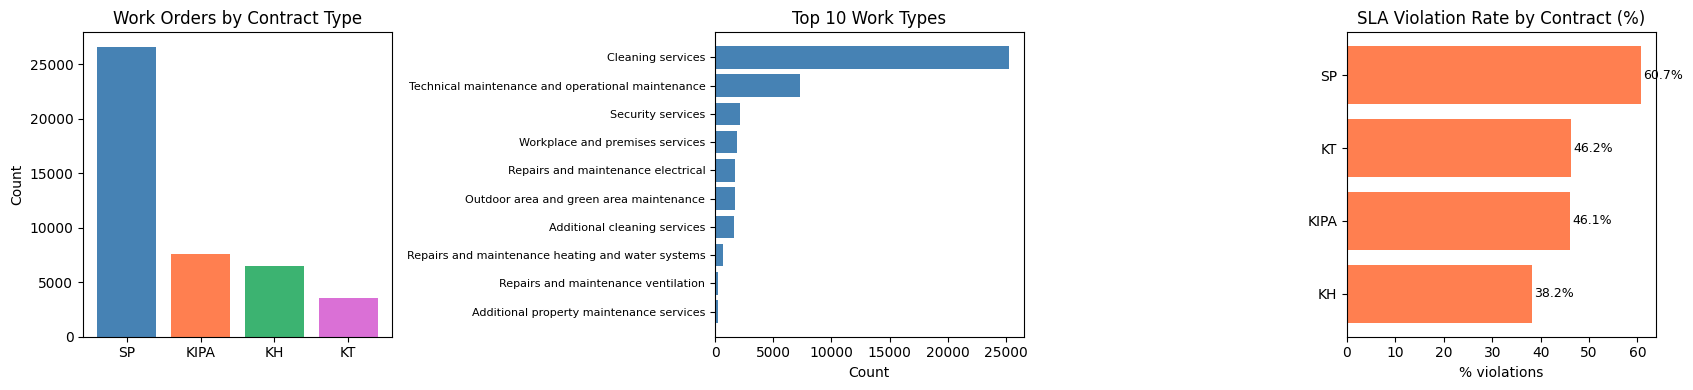

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Contract breakdown
contract_counts = wo["CONTRACT"].value_counts()
axes[0].bar(contract_counts.index, contract_counts.values, color=["steelblue","coral","mediumseagreen","orchid"])
axes[0].set_title("Work Orders by Contract Type")
axes[0].set_ylabel("Count")

# Top 10 work types
top_types = wo["WORK_TYPE_DESCRIPTION_ENG"].value_counts().head(10)
axes[1].barh(top_types.index[::-1], top_types.values[::-1], color="steelblue")
axes[1].set_title("Top 10 Work Types")
axes[1].set_xlabel("Count")
axes[1].tick_params(axis="y", labelsize=8)

# SLA violations by contract
sla_df = wo[wo["IS_SLA_VIOLATION"].notna()].copy()
sla_df["IS_SLA_VIOLATION"] = pd.to_numeric(sla_df["IS_SLA_VIOLATION"], errors="coerce")
sla_rate = sla_df.groupby("CONTRACT")["IS_SLA_VIOLATION"].mean().mul(100).round(1).sort_values()
bars = axes[2].barh(sla_rate.index, sla_rate.values, color="coral")
axes[2].set_title("SLA Violation Rate by Contract (%)")
axes[2].set_xlabel("% violations")
for bar, val in zip(bars, sla_rate.values):
    axes[2].text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()


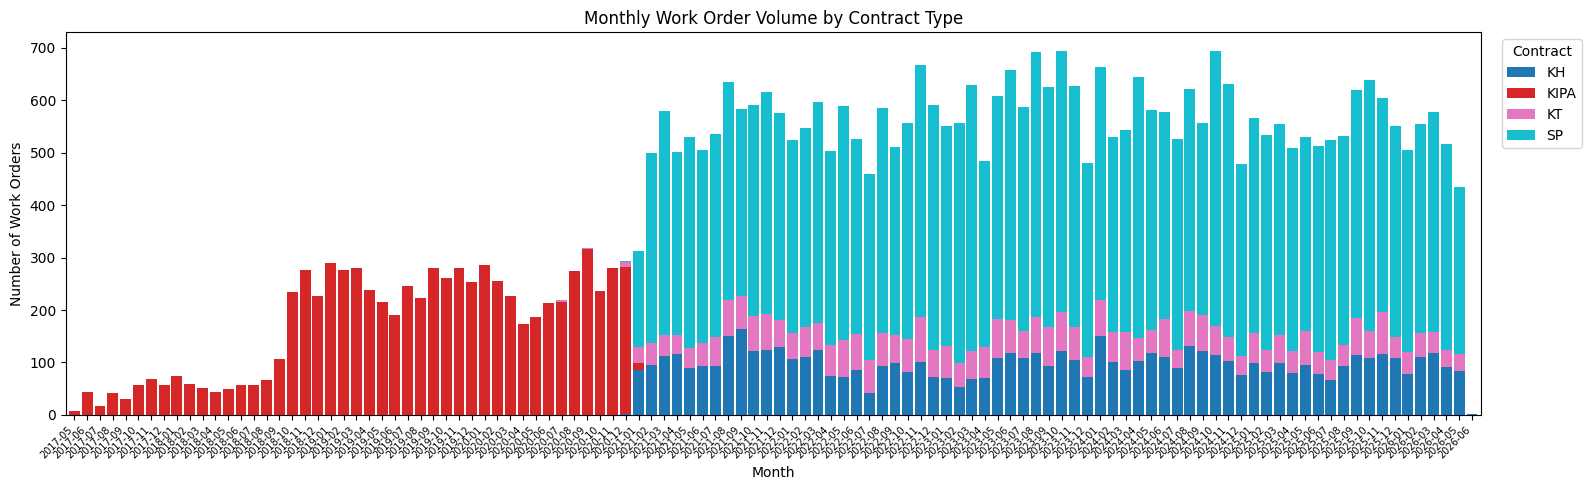

In [32]:
# Monthly work order volume by contract
wo["wo_month"] = wo["WORK_STARTED_DATETIME"].dt.to_period("M")
monthly_wo = (
    wo.groupby(["wo_month", "CONTRACT"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(16, 5))
monthly_wo.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.85)
ax.set_title("Monthly Work Order Volume by Contract Type")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Work Orders")
ax.set_xticklabels([str(p) for p in monthly_wo.index], rotation=45, ha="right", fontsize=7)
ax.legend(title="Contract", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [33]:
# Null analysis (only columns with nulls)
wo_nulls = wo.isnull().sum()
wo_nulls_pct = (wo_nulls / len(wo) * 100).round(1)
wo_quality = pd.DataFrame({"null_count": wo_nulls, "null_%": wo_nulls_pct})
wo_quality[wo_quality["null_count"] > 0].sort_values("null_%", ascending=False)


,null_count,null_%
PM_NO,41024,92.7
PM_ACTION_DESCR,41024,92.7
ASSIGNMENT_TYPE,32444,73.3
ASSIGNMENT_TYPE_ENG,32444,73.3
PRIORITY_ID,31724,71.7
WORK_ORDER_PERFORMED_ACTION,30974,70.0
WORK_DESCRIPTION,30631,69.2
SLA_REQUIRED_END_DATETIME,10647,24.1
WORKTIME_HOURS,6542,14.8
WORK_FINISHED_DAYS,1477,3.3


---
# Maintenance Schedule

316 rows (106 unique plans, each duplicated 3× — export artifact). Covers Lentokentänkatu 11 and Venttiilitehdas.

In [34]:
pm = pd.read_csv(
    "Luotea-Hackathon-2026/Maintenance schedule (EH-työt)/Scheduled maitenance plans.csv",
    encoding="utf-8-sig",
)
pm_dedup = pm.drop_duplicates(subset="PM_NO")

print(f"Raw rows: {len(pm)}  |  Unique plans (after dedup): {len(pm_dedup)}")
print(f"\nStatus:\n{pm_dedup['OBJSTATE'].value_counts().to_string()}")
print(f"\nSites:\n{pm_dedup['customer_site_name'].value_counts().to_string()}")
print(f"\nInterval units:\n{pm_dedup['PM_INTERVAL_UNIT'].value_counts(dropna=False).to_string()}")


Raw rows: 316  |  Unique plans (after dedup): 106

Status:
OBJSTATE
Active      66
Obsolete    40

Sites:
customer_site_name
Lentokentänkatu 11    59
Venttiilitehdas       46
STD tehdas             1

Interval units:
PM_INTERVAL_UNIT
Year     55
NaN      29
Month    10
Day       8
Week      4


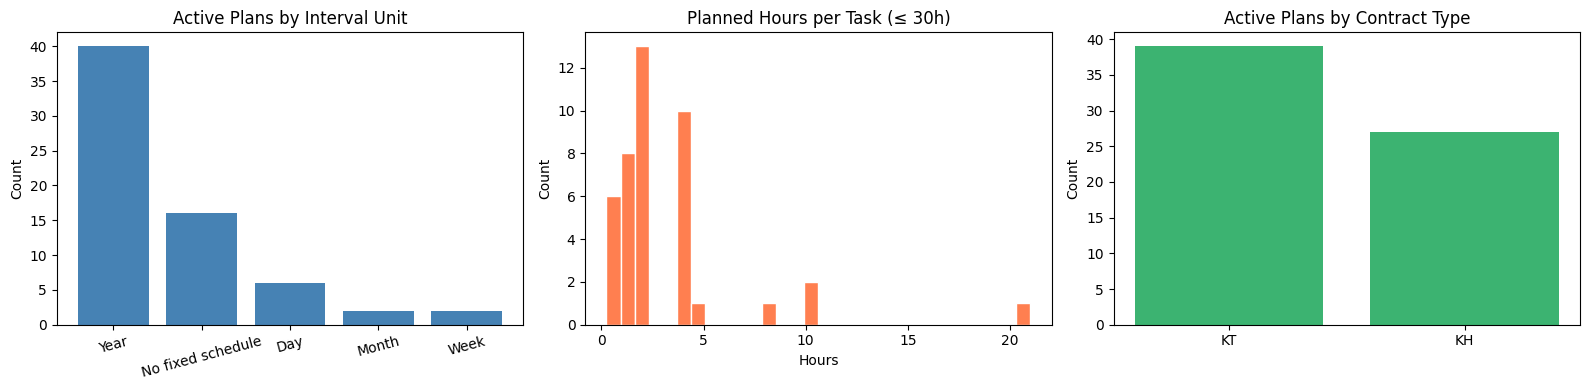


Top 10 maintenance activities (active):
ACTION_DESCR_ENG
Scheduled maintenance, electrical                                16
Manual cleaning of outdoor areas P1-P6                            4
Scheduled maintenance, ventilation, spring                        3
Scheduled maintenance, fire safety                                3
Lawn mowing A1-A3                                                 3
Scheduled maintenance, property refrigeration systems, spring     2
Scheduled maintenance, building automation                        2
Scheduled maintenance, heating and water systems                  2
Maintenance of fire alarm systems                                 2
Weekly inspection round                                           2


In [35]:
active = pm_dedup[pm_dedup["OBJSTATE"] == "Active"].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Interval unit breakdown (active plans)
interval_counts = active["PM_INTERVAL_UNIT"].value_counts(dropna=False)
interval_counts.index = interval_counts.index.fillna("No fixed schedule")
axes[0].bar(interval_counts.index, interval_counts.values, color="steelblue")
axes[0].set_title("Active Plans by Interval Unit")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)

# Planned hours distribution (active, non-null)
plan_hrs = active["PLAN_HRS"].dropna()
axes[1].hist(plan_hrs[plan_hrs <= 30], bins=30, color="coral", edgecolor="white")
axes[1].set_title("Planned Hours per Task (≤ 30h)")
axes[1].set_xlabel("Hours")
axes[1].set_ylabel("Count")

# Contract type breakdown (active)
contract_pm = active["MCH_CODE_CONTRACT"].value_counts()
axes[2].bar(contract_pm.index, contract_pm.values, color="mediumseagreen")
axes[2].set_title("Active Plans by Contract Type")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"\nTop 10 maintenance activities (active):")
print(active["ACTION_DESCR_ENG"].value_counts().head(10).to_string())


---
# Cleaning Robots

Two Gausium robots at Lentokentänkatu 11: **Phantas** (vacuum, 332 tasks since May 2024) and **Scrub 50** (wet scrubber, 4,346 tasks since Apr 2022).

In [46]:
phantas = pd.read_excel("Luotea-Hackathon-2026/Cleaning Robots/TaskReport, Phantas, Valmet FC lentokentänkatu 11..xlsx")
scrub = pd.read_excel("Luotea-Hackathon-2026/Cleaning Robots/TaskReport, Scrub 50, Valmet FC lentokentänkatu 11..xlsx")

for name, r in [("Phantas", phantas), ("Scrub 50", scrub)]:
    r["Task start time"] = pd.to_datetime(r["Task start time"])
    r["completion"] = pd.to_numeric(r["Task completion (%)"], errors="coerce")
    print(f"=== {name} ===")
    print(f"  Tasks: {len(r):,}  |  Date range: {r['Task start time'].min().date()} → {r['Task start time'].max().date()}")
    print(f"  Avg completion: {r['completion'].mean():.1f}%")
    print(f"  Task status: {r['Task status'].value_counts().to_dict()}")
    print(f"  Maps: {r['Map name'].value_counts().to_dict()}")
    print()


=== Phantas ===
  Tasks: 332  |  Date range: 2024-05-23 → 2026-06-03
  Avg completion: 39.3%
  Task status: {'Normal end': 233, 'Manual termination': 99}
  Maps: {'Moduuli30': 184, 'Moduuli90': 52, 'Moduuli100': 49, 'Moduuli75': 33, 'office': 12, 'testi': 2}

=== Scrub 50 ===
  Tasks: 4,346  |  Date range: 2022-04-01 → 2026-05-28
  Avg completion: 47.8%
  Task status: {'Normal end': 3787, 'Manual termination': 559}
  Maps: {'Valmet_2krs': 2318, 'Valmet_Luiska': 1705, 'Valmet_1krs': 301, 'Valmet_K_krs': 10, 'ttt': 9, 'raksila': 3}



/tmp/ipykernel_14735/210615152.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row_idx, 2].boxplot(wear_data, labels=[c.replace(" (%)", "").replace("(%)","") for c in wear_cols])
/tmp/ipykernel_14735/210615152.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row_idx, 2].boxplot(wear_data, labels=[c.replace(" (%)", "").replace("(%)","") for c in wear_cols])


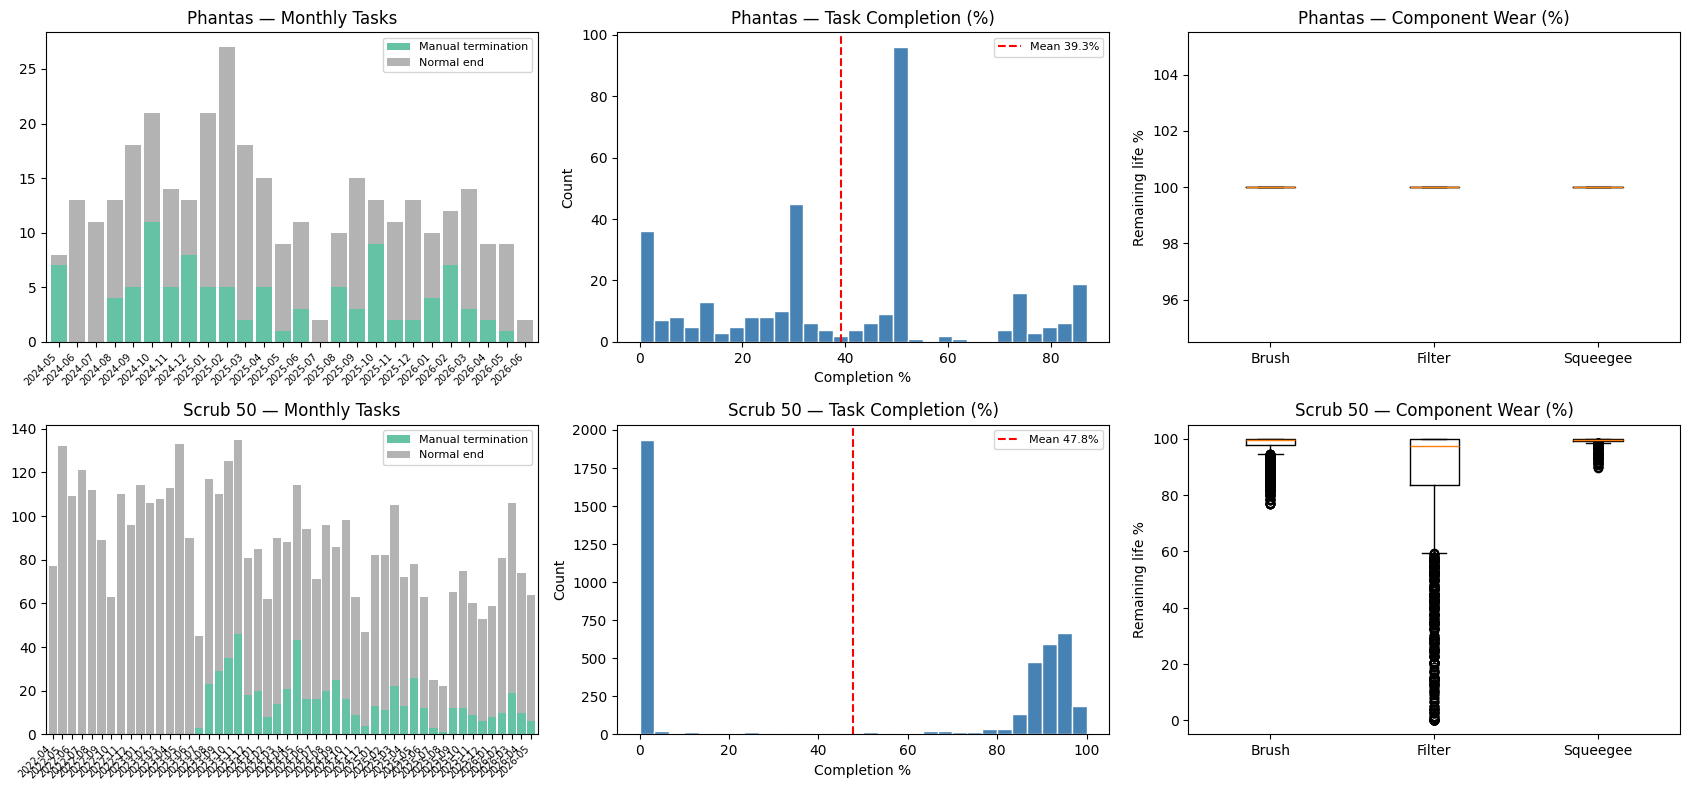

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))

for row_idx, (name, r) in enumerate([("Phantas", phantas), ("Scrub 50", scrub)]):
    r["month"] = r["Task start time"].dt.to_period("M")

    # Monthly task count coloured by status
    monthly_status = r.groupby(["month", "Task status"]).size().unstack(fill_value=0).sort_index()
    monthly_status.plot(kind="bar", stacked=True, ax=axes[row_idx, 0], colormap="Set2", width=0.85)
    axes[row_idx, 0].set_title(f"{name} — Monthly Tasks")
    axes[row_idx, 0].set_xlabel("")
    axes[row_idx, 0].set_xticklabels([str(p) for p in monthly_status.index], rotation=45, ha="right", fontsize=7)
    axes[row_idx, 0].legend(fontsize=8)

    # Task completion distribution
    axes[row_idx, 1].hist(r["completion"].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[row_idx, 1].set_title(f"{name} — Task Completion (%)")
    axes[row_idx, 1].set_xlabel("Completion %")
    axes[row_idx, 1].set_ylabel("Count")
    axes[row_idx, 1].axvline(r["completion"].mean(), color="red", linestyle="--", label=f"Mean {r['completion'].mean():.1f}%")
    axes[row_idx, 1].legend(fontsize=8)

    # Component wear
    wear_cols = [c for c in ["Brush (%)", "Filter (%)", "Squeegee(%)"] if c in r.columns]
    wear_data = [pd.to_numeric(r[c], errors="coerce").dropna() for c in wear_cols]
    axes[row_idx, 2].boxplot(wear_data, labels=[c.replace(" (%)", "").replace("(%)","") for c in wear_cols])
    axes[row_idx, 2].set_title(f"{name} — Component Wear (%)")
    axes[row_idx, 2].set_ylabel("Remaining life %")

plt.tight_layout()
plt.show()


---
# Desk & Room Utilization (Need-Based Cleaning)

176 desks and 38 meeting rooms at Lentokentänkatu 11, Jan 2024–May 2026. Values = minutes of use per working day.

In [48]:
import glob, os

desk_files = sorted(glob.glob(
    "Luotea-Hackathon-2026/need-based cleaning/"
    "Valmet Technologies Oy Lentokentänkatu 11 Desk Utilization*/*.csv"
))
room_files = sorted(glob.glob(
    "Luotea-Hackathon-2026/need-based cleaning/"
    "Valmet Technologies Oy Lentokentänkatu 11 Room Utilization*/*.csv"
))

def load_wide_csvs(files):
    frames = []
    for f in files:
        df_w = pd.read_csv(f, encoding="utf-8-sig", index_col=0)
        frames.append(df_w)
    combined = pd.concat(frames, axis=1)
    combined = combined.loc[:, ~combined.columns.duplicated()]
    combined.columns = pd.to_datetime(combined.columns)
    return combined.sort_index(axis=1)

desks = load_wide_csvs(desk_files)
rooms = load_wide_csvs(room_files)

print(f"Desks: {desks.shape[0]} assets × {desks.shape[1]} days  ({desks.columns[0].date()} → {desks.columns[-1].date()})")
print(f"Rooms: {rooms.shape[0]} assets × {rooms.shape[1]} days  ({rooms.columns[0].date()} → {rooms.columns[-1].date()})")
print(f"\nDesk utilization stats (minutes/day):")
print(desks.stack().describe().round(1))


Desks: 176 assets × 628 days  (2024-01-01 → 2026-05-27)
Rooms: 38 assets × 628 days  (2024-01-01 → 2026-05-27)

Desk utilization stats (minutes/day):
count    110528.0
mean         26.5
std          34.2
min           0.0
25%           0.0
50%           0.0
75%          64.1
max         100.0
dtype: float64


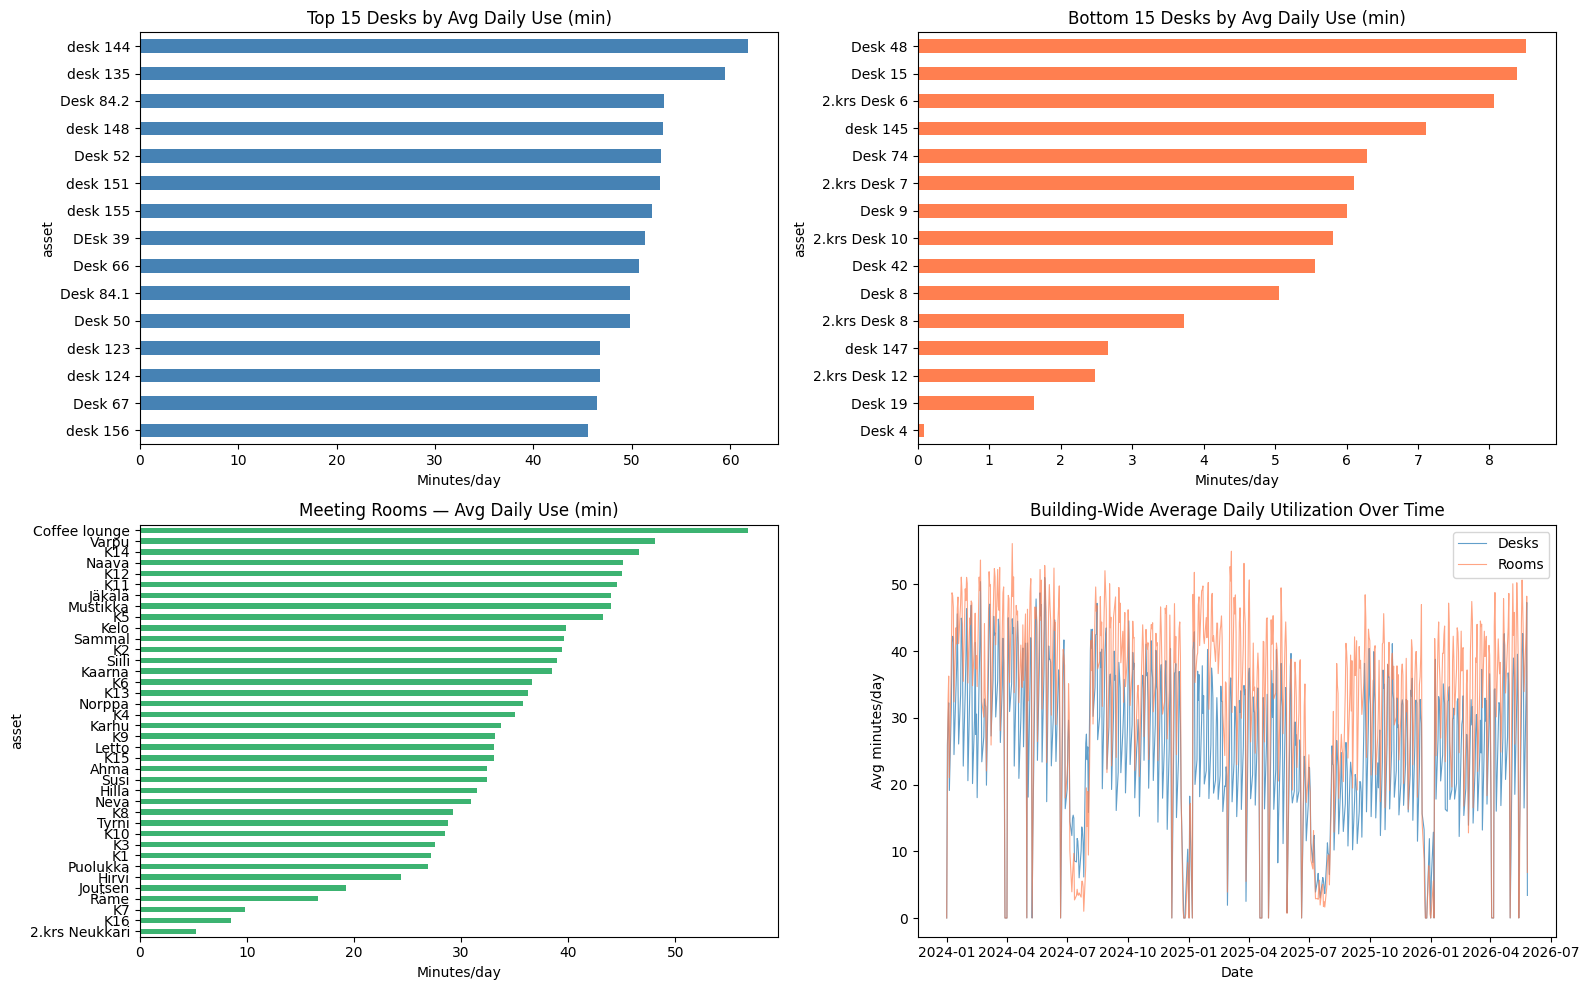

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Mean daily utilization per desk (top/bottom 15)
desk_means = desks.mean(axis=1).sort_values(ascending=False)
desk_means.head(15).plot(kind="barh", ax=axes[0, 0], color="steelblue")
axes[0, 0].invert_yaxis()
axes[0, 0].set_title("Top 15 Desks by Avg Daily Use (min)")
axes[0, 0].set_xlabel("Minutes/day")

desk_means.tail(15).plot(kind="barh", ax=axes[0, 1], color="coral")
axes[0, 1].invert_yaxis()
axes[0, 1].set_title("Bottom 15 Desks by Avg Daily Use (min)")
axes[0, 1].set_xlabel("Minutes/day")

# Mean daily utilization per room
room_means = rooms.mean(axis=1).sort_values(ascending=False)
room_means.plot(kind="barh", ax=axes[1, 0], color="mediumseagreen")
axes[1, 0].invert_yaxis()
axes[1, 0].set_title("Meeting Rooms — Avg Daily Use (min)")
axes[1, 0].set_xlabel("Minutes/day")

# Building-wide daily average over time
daily_avg_desk = desks.mean(axis=0)
daily_avg_room = rooms.mean(axis=0)
axes[1, 1].plot(daily_avg_desk.index, daily_avg_desk.values, label="Desks", alpha=0.7, linewidth=0.8)
axes[1, 1].plot(daily_avg_room.index, daily_avg_room.values, label="Rooms", alpha=0.7, linewidth=0.8, color="coral")
axes[1, 1].set_title("Building-Wide Average Daily Utilization Over Time")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Avg minutes/day")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


---
# Sensor Metadata

389 IoT sensors at Lentokentänkatu 11. All active. Covers desks, meeting rooms, WC counters, dispensers, and gateways.

In [50]:
sensors = pd.read_excel(
    "Luotea-Hackathon-2026/need-based cleaning/Valmet_sensoritiedot.xlsx",
    sheet_name="Data",
)

print(f"Total sensors: {len(sensors)}")
print(f"\nBy type:\n{sensors['Sensorityyppi'].value_counts().to_string()}")
print(f"\nBy room type (Tilatyyppi):\n{sensors['Tilatyyppi'].value_counts(dropna=False).to_string()}")
print(f"\nBy floor (Kerros):\n{sensors['Kerros'].value_counts(dropna=False).to_string()}")
print(f"\nBattery level — mean: {sensors['battery level'].mean():.2%}, min: {sensors['battery level'].min():.2%}")
print(f"\nColumns with 100% nulls:")
print([c for c in sensors.columns if sensors[c].isnull().all()])


Total sensors: 389

By type:
Sensorityyppi
occupancy    214
distance     140
counter       31
gateway        4

By room type (Tilatyyppi):
Tilatyyppi
Pöytä          176
Annostelija    123
Neuvottelu      38
WC              31
Roska-astia     17
Gateway          4

By floor (Kerros):
Kerros
1.0     305
2.0      79
NaN       4
22.0      1

Battery level — mean: 86.83%, min: 0.00%

Columns with 100% nulls:
['Asennuspäivä', 'Koordinaatti', 'Tarkkuusluokka', 'Pinta-ala', 'Kapasiteetti', 'Käyttötarkoitus', 'Aukiopoajat', 'koordinaatit']


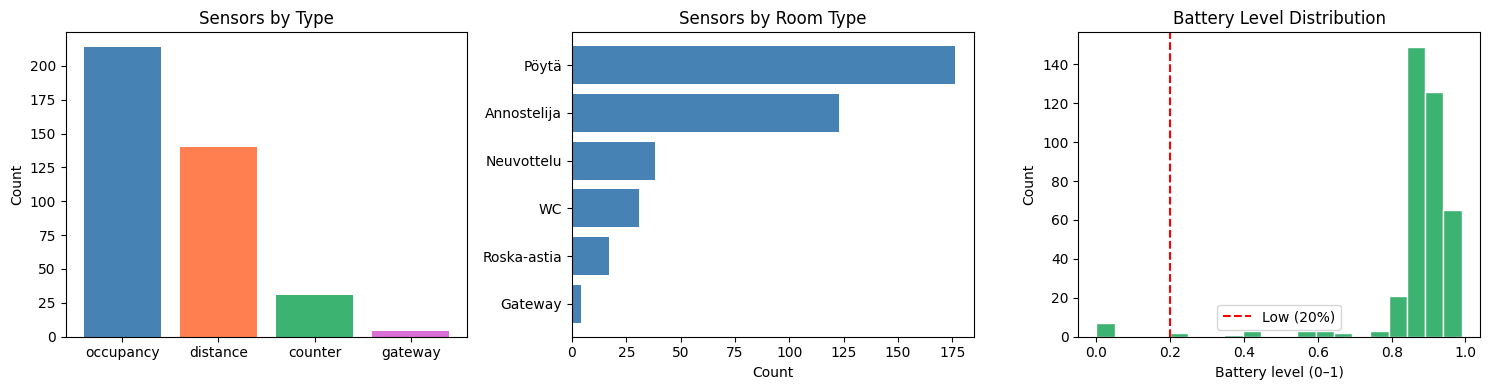

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sensor type breakdown
s_type = sensors["Sensorityyppi"].value_counts()
axes[0].bar(s_type.index, s_type.values, color=["steelblue","coral","mediumseagreen","orchid"])
axes[0].set_title("Sensors by Type")
axes[0].set_ylabel("Count")

# Room type breakdown
s_room = sensors["Tilatyyppi"].value_counts(dropna=False)
s_room.index = s_room.index.fillna("Unknown")
axes[1].barh(s_room.index[::-1], s_room.values[::-1], color="steelblue")
axes[1].set_title("Sensors by Room Type")
axes[1].set_xlabel("Count")

# Battery distribution
axes[2].hist(sensors["battery level"].dropna(), bins=20, color="mediumseagreen", edgecolor="white")
axes[2].set_title("Battery Level Distribution")
axes[2].set_xlabel("Battery level (0–1)")
axes[2].set_ylabel("Count")
axes[2].axvline(0.2, color="red", linestyle="--", label="Low (20%)")
axes[2].legend()

plt.tight_layout()
plt.show()


---
# Smartti — Energy & Climate Data

Energy (hourly) and indoor climate data for 4 properties. Aurora House, Horizon Plaza, Meridian Tower (anonymous) + Valmet Flow Control. Data from 2021 onwards.

In [54]:
import json

summaries = []
for fname, label in [
    ("Luotea-Hackathon-2026/Smartti/aurora_house.json", "Aurora House"),
    ("Luotea-Hackathon-2026/Smartti/horizon_plaza.json", "Horizon Plaza"),
    ("Luotea-Hackathon-2026/Smartti/valmet_flow_control.json", "Valmet Flow Control"),
]:
    with open(fname) as f:
        d = json.load(f)
    prop = d["property"]
    readings = prop.get("readings", {})
    row = {"property": label, "nodes": len(prop.get("nodes", [])), "incidents": len(prop.get("incidents", []))}
    for metric, v in readings.items():
        row[metric + "_count"] = v["count"]
        row[metric + "_from"] = v["earliest"][:10]
        row[metric + "_to"] = v["latest"][:10]
    summaries.append(row)

summary_df = pd.DataFrame(summaries).set_index("property")
print("Readings per property:")
count_cols = [c for c in summary_df.columns if c.endswith("_count")]
print(summary_df[["nodes", "incidents"] + count_cols].to_string())


Readings per property:
                     nodes  incidents  district_heating_MWh_count  electricity_kWh_count  interior_co2_ppm_count  interior_temperature_C_count  interior_temperature_target_C_count  interior_temperature_tolerance_C_count  water_m3_count  district_cooling_MWh_count
property                                                                                                                                                                                                                                                               
Aurora House            48         90                       43737                  45453                     808                         44921                                  260                                     171           43866                         NaN
Horizon Plaza           50        153                       28789                  45624                     314                         25577                                 2096      

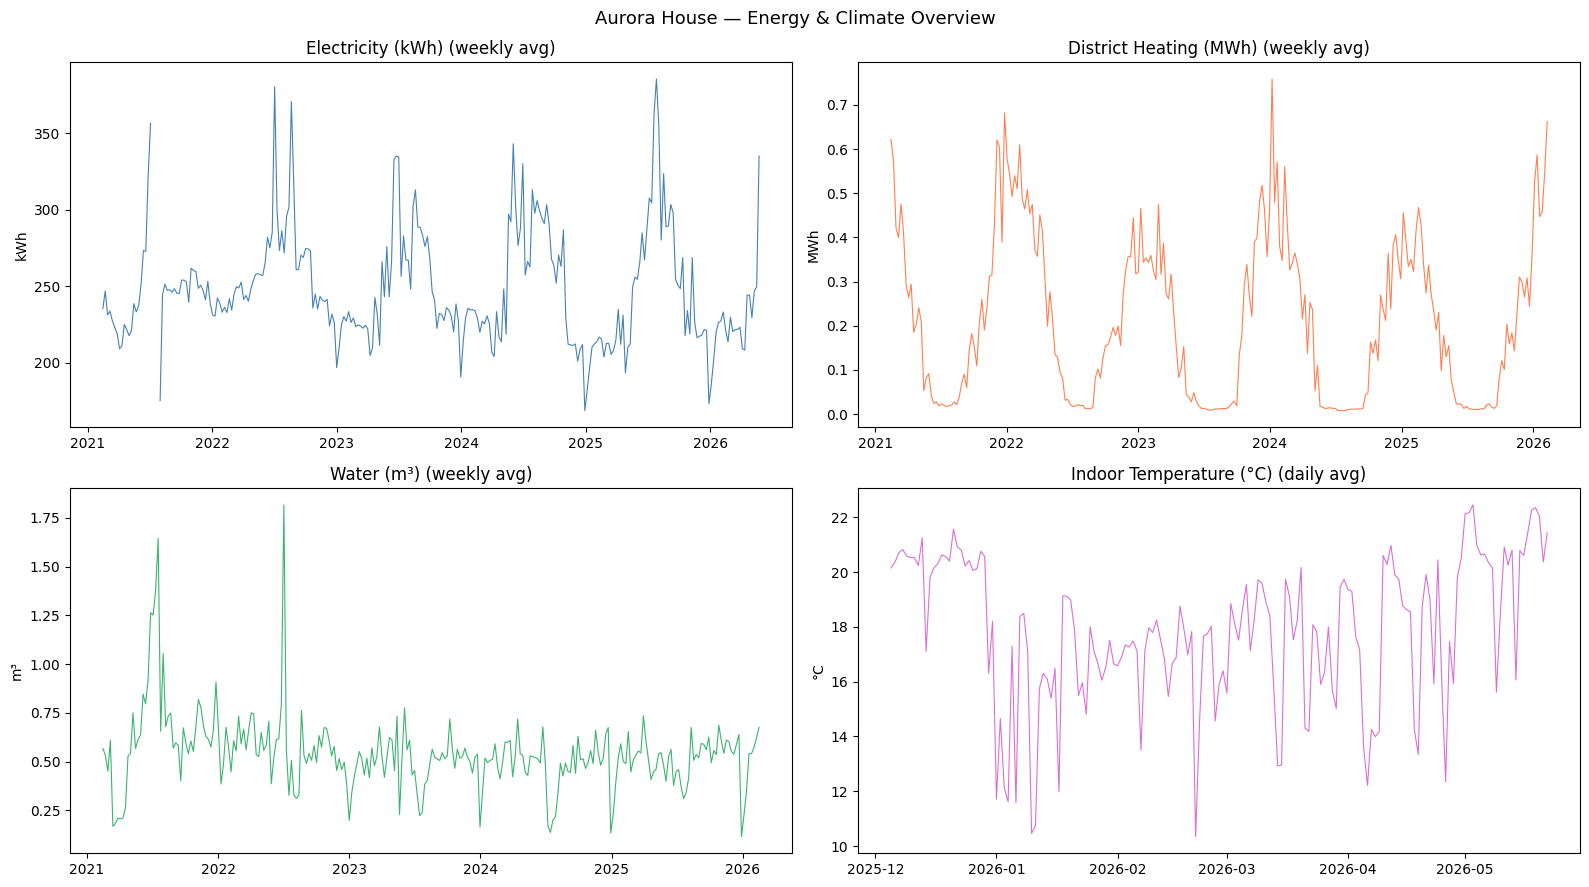

In [55]:
# Load Aurora House energy readings and plot
with open("Luotea-Hackathon-2026/Smartti/aurora_house.json") as f:
    aurora = json.load(f)

prop = aurora["property"]
readings = prop["readings"]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("Aurora House — Energy & Climate Overview", fontsize=13)

metric_cfg = [
    ("electricity_kWh", "Electricity (kWh)", "steelblue", axes[0, 0]),
    ("district_heating_MWh", "District Heating (MWh)", "coral", axes[0, 1]),
    ("water_m3", "Water (m³)", "mediumseagreen", axes[1, 0]),
    ("interior_temperature_C", "Indoor Temperature (°C)", "orchid", axes[1, 1]),
]

for metric, label, color, ax in metric_cfg:
    if metric not in readings:
        ax.set_visible(False)
        continue
    data = pd.DataFrame(readings[metric]["data"])
    data["t"] = pd.to_datetime(data["t"], format="ISO8601", utc=True)
    data = data.set_index("t").sort_index()
    freq = "D" if metric == "interior_temperature_C" else "W"
    resampled = data["v"].resample(freq).mean()
    ax.plot(resampled.index, resampled.values, linewidth=0.8, color=color)
    ax.set_title(f"{label} (weekly avg)" if freq == "W" else f"{label} (daily avg)")
    ax.set_xlabel("")
    ax.set_ylabel(label.split("(")[1].rstrip(")"))

plt.tight_layout()
plt.show()

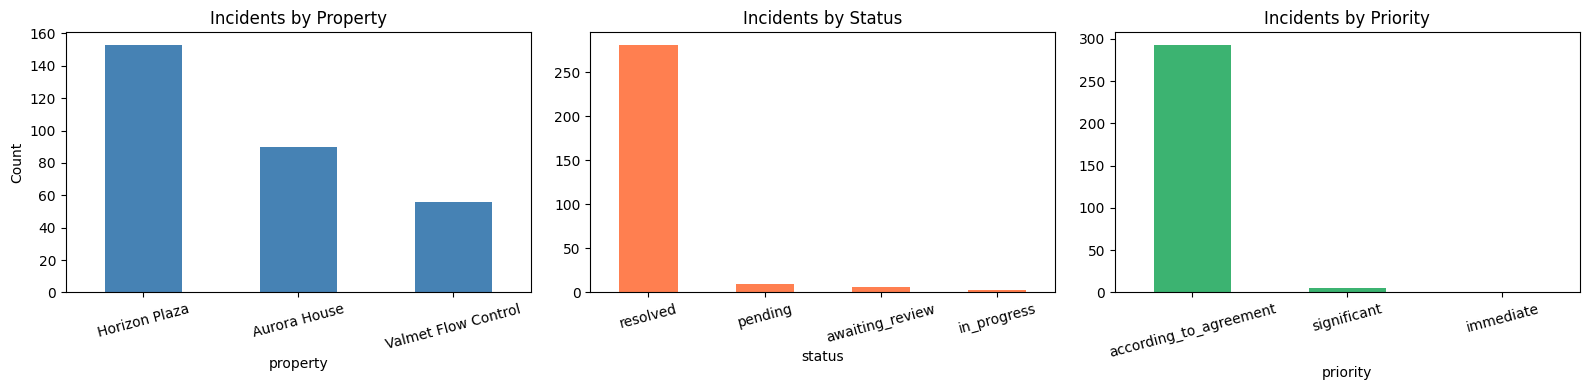


Total incidents (3 properties): 299
Event types:
event_type
Vikailmoitus                        140
Muu huomio                           53
Energiansäästötoimenpide             53
Asetusarvomuutos                     19
Aikaohjelmien tarkastus              13
Lämpötilaolosuhteet                  10
Kiinteistönhoitajan kontaktointi      7
Koontiraportti                        1


In [56]:
# Incidents summary across properties
incident_rows = []
for fname, label in [
    ("Luotea-Hackathon-2026/Smartti/aurora_house.json", "Aurora House"),
    ("Luotea-Hackathon-2026/Smartti/horizon_plaza.json", "Horizon Plaza"),
    ("Luotea-Hackathon-2026/Smartti/valmet_flow_control.json", "Valmet Flow Control"),
]:
    with open(fname) as f:
        d = json.load(f)
    for inc in d["property"].get("incidents", []):
        incident_rows.append({
            "property": label,
            "created_at": inc["created_at"][:10],
            "event_type": inc.get("event_type", ""),
            "priority": inc.get("priority", ""),
            "status": inc.get("status", ""),
            "category": inc.get("category", ""),
        })

incidents_df = pd.DataFrame(incident_rows)
incidents_df["created_at"] = pd.to_datetime(incidents_df["created_at"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# By property
incidents_df["property"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Incidents by Property")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)

# By status
incidents_df["status"].value_counts().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Incidents by Status")
axes[1].tick_params(axis="x", rotation=15)

# By priority
incidents_df["priority"].value_counts().plot(kind="bar", ax=axes[2], color="mediumseagreen")
axes[2].set_title("Incidents by Priority")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()
print(f"\nTotal incidents (3 properties): {len(incidents_df)}")
print(f"Event types:\n{incidents_df['event_type'].value_counts().head(8).to_string()}")


---
# Maintenance Reports (KTE + STP)

Structured extracts from PDF maintenance reports. KTE = technical maintenance (395 reports, 2022–2026). STP = cleaning quality inspections (90 reports, scored 1–5).

In [57]:
kte = pd.read_excel(
    "Luotea-Hackathon-2026/Huoltoraportit/Huoltoraporttien tiedot Valmetit.xlsx",
    sheet_name="KTE",
)
stp = pd.read_excel(
    "Luotea-Hackathon-2026/Huoltoraportit/Huoltoraporttien tiedot Valmetit.xlsx",
    sheet_name="STP",
)

# Normalise site names
def normalise_site(s):
    s = str(s).lower()
    if "lentok" in s or "tampere" in s:
        return "Lentokentänkatu 11"
    if "venttiili" in s:
        return "Venttiilitehdas"
    if "toimisto" in s:
        return "Toimistotalo"
    if "std" in s:
        return "STD tehdas"
    return "Other"

kte["site"] = kte["Kohde"].apply(normalise_site)
stp["site"] = stp["Kohde"].apply(normalise_site)
kte["Pvm"] = pd.to_datetime(kte["Pvm"], errors="coerce")
stp["Pvm"] = pd.to_datetime(stp["Pvm"], errors="coerce")

print(f"KTE: {len(kte)} reports  |  Sites: {kte['site'].value_counts().to_dict()}")
print(f"STP: {len(stp)} reports  |  Sites: {stp['site'].value_counts().to_dict()}")
print(f"\nKTE date range: {kte['Pvm'].min().date()} → {kte['Pvm'].max().date()}")
print(f"STP date range: {stp['Pvm'].min().date()} → {stp['Pvm'].max().date()}")


KTE: 395 reports  |  Sites: {'Other': 218, 'Venttiilitehdas': 169, 'Toimistotalo': 4, 'Lentokentänkatu 11': 2, 'STD tehdas': 2}
STP: 90 reports  |  Sites: {'Venttiilitehdas': 55, 'Other': 33, 'Toimistotalo': 1, 'STD tehdas': 1}

KTE date range: 2022-01-24 → 2026-05-19
STP date range: 2023-01-16 → 2026-12-05


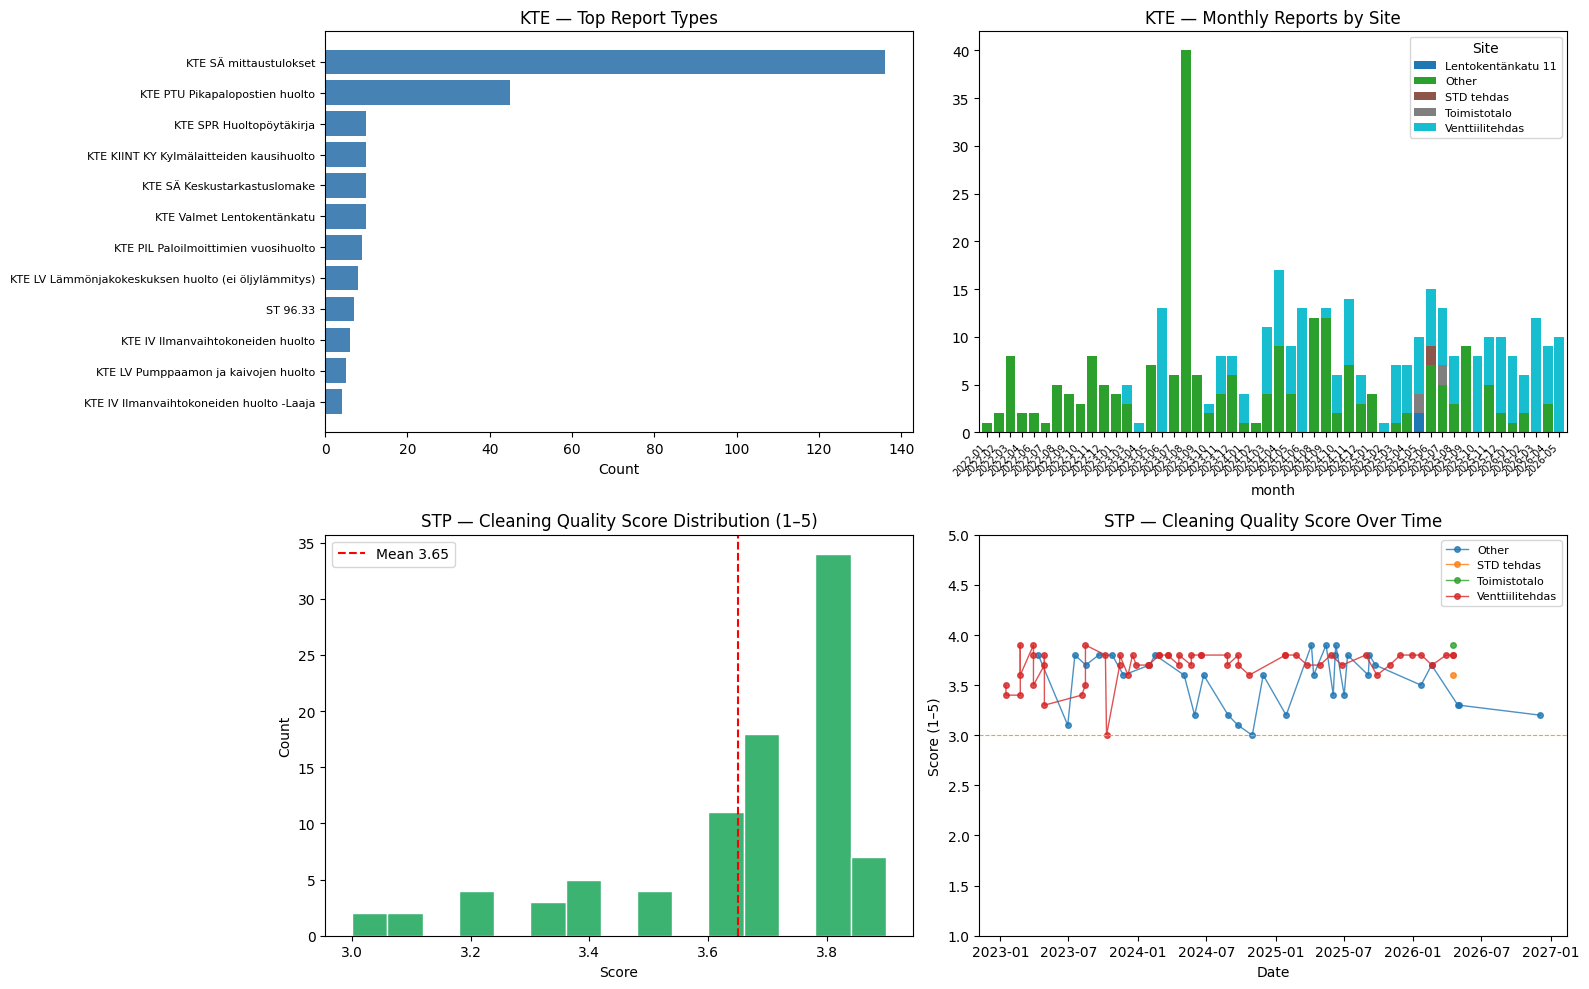

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# KTE: report types
top_types = kte["Raporttipohja"].value_counts().dropna().head(12)
axes[0, 0].barh(top_types.index[::-1], top_types.values[::-1], color="steelblue")
axes[0, 0].set_title("KTE — Top Report Types")
axes[0, 0].set_xlabel("Count")
axes[0, 0].tick_params(axis="y", labelsize=8)

# KTE: monthly volume by site
kte["month"] = kte["Pvm"].dt.to_period("M")
kte_monthly = kte.groupby(["month", "site"]).size().unstack(fill_value=0).sort_index()
kte_monthly.plot(kind="bar", stacked=True, ax=axes[0, 1], colormap="tab10", width=0.85)
axes[0, 1].set_title("KTE — Monthly Reports by Site")
axes[0, 1].set_xticklabels([str(p) for p in kte_monthly.index], rotation=45, ha="right", fontsize=7)
axes[0, 1].legend(title="Site", fontsize=8)

# STP: quality scores distribution
axes[1, 0].hist(stp["Arvioinnin keskiarvo"].dropna(), bins=15, color="mediumseagreen", edgecolor="white")
axes[1, 0].set_title("STP — Cleaning Quality Score Distribution (1–5)")
axes[1, 0].set_xlabel("Score")
axes[1, 0].set_ylabel("Count")
axes[1, 0].axvline(stp["Arvioinnin keskiarvo"].mean(), color="red", linestyle="--",
                   label=f"Mean {stp['Arvioinnin keskiarvo'].mean():.2f}")
axes[1, 0].legend()

# STP: scores over time by site
for site, grp in stp.groupby("site"):
    grp_sorted = grp.dropna(subset=["Pvm"]).sort_values("Pvm")
    axes[1, 1].plot(grp_sorted["Pvm"], grp_sorted["Arvioinnin keskiarvo"], marker="o",
                    markersize=4, linewidth=1, label=site, alpha=0.8)
axes[1, 1].set_title("STP — Cleaning Quality Score Over Time")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Score (1–5)")
axes[1, 1].set_ylim(1, 5)
axes[1, 1].legend(fontsize=8)
axes[1, 1].axhline(3, color="orange", linestyle="--", linewidth=0.8, label="Threshold 3")

plt.tight_layout()
plt.show()
